<a href="https://colab.research.google.com/github/JayaGenZKece/Muhammad-Jaya-Subakhan_23424046/blob/main/Tugasbaru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

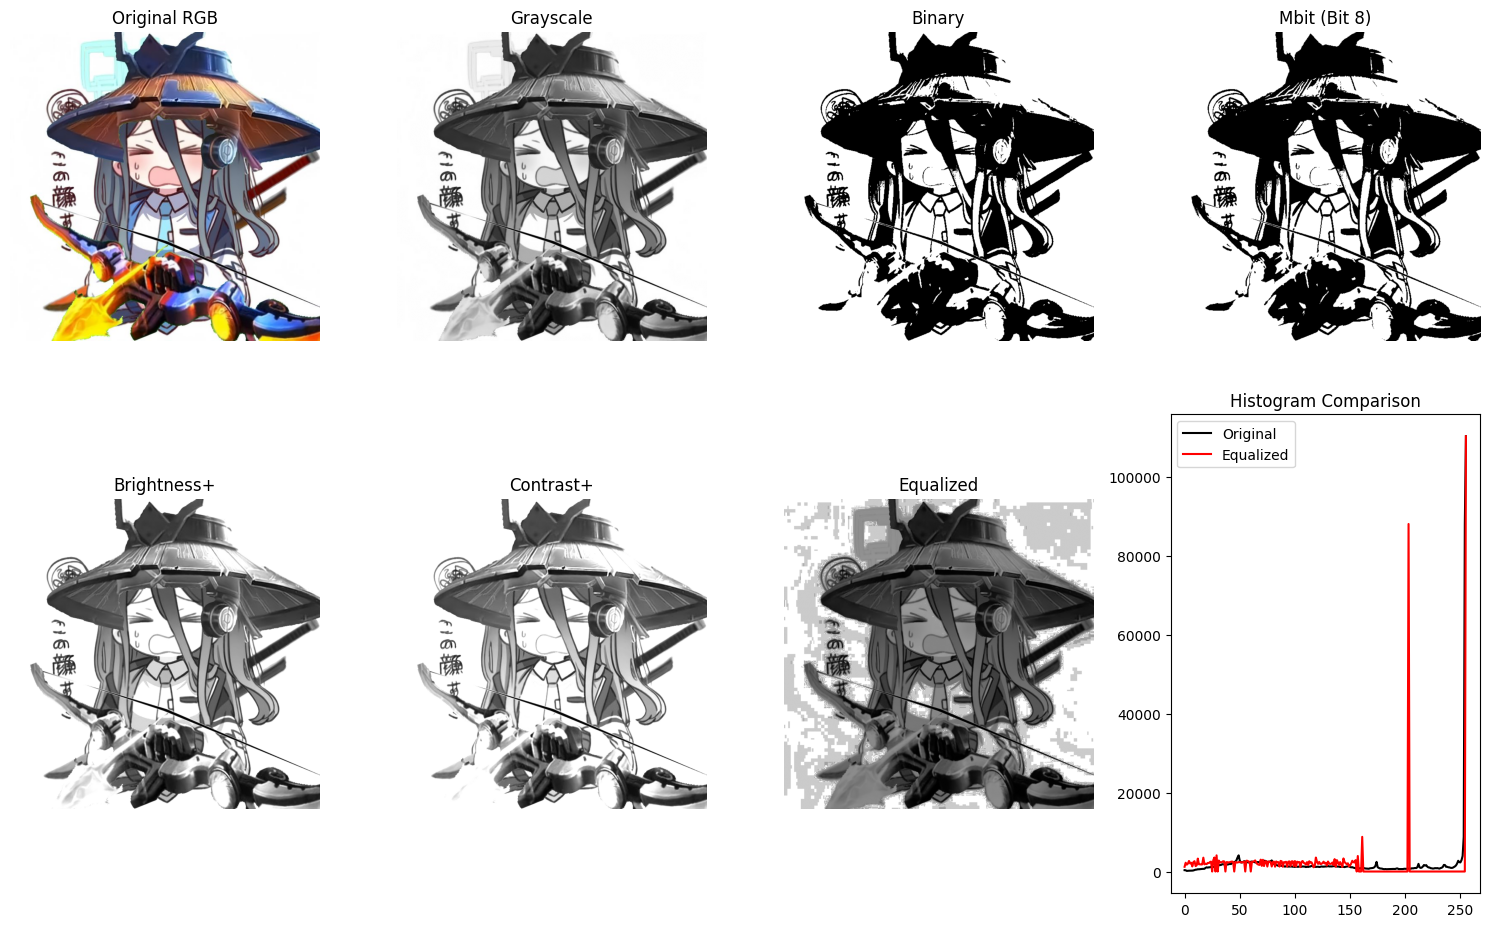

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load gambar (ganti 'cool.jpg' dengan file kamu, atau upload ke Colab)
img_rgb = cv2.imread('yss.jpg')

# Periksa apakah gambar berhasil dimuat
if img_rgb is None:
    print("Error: Could not load image. Please ensure 'cool.jpg' is in the correct directory or upload the image.")
else:
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB) # Konversi BGR ke RGB untuk Matplotlib

    # 1. Konversi RGB ke Grayscale
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # 2. Konversi Grayscale ke Biner (Thresholding)
    # Nilai 127 adalah ambang batas (threshold)
    _, img_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    # 3. Konversi Grayscale ke Mbit (Bit-plane Slicing - Contoh Bit ke-8)
    # Ini mengambil informasi paling signifikan dari gambar
    img_mbit = (img_gray & 0b10000000)

    # 4. Image Brightness (Kecerahan)
    # Menambah nilai pixel (misal +50)
    img_brightness = cv2.convertScaleAbs(img_gray, alpha=1, beta=50)

    # 5. Image Contrast (Kontras)
    # Mengalikan nilai pixel (misal x1.5)
    img_contrast = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=0)

    # 6. Grayscale to Histogram
    hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

    # 7. Histogram Equalization
    img_equalized = cv2.equalizeHist(img_gray)
    hist_equalized = cv2.calcHist([img_equalized], [0], None, [256], [0, 256])

    # --- VISUALISASI ---
    plt.figure(figsize=(15, 10))

    titles = ['Original RGB', 'Grayscale', 'Binary', 'Mbit (Bit 8)',
              'Brightness+', 'Contrast+', 'Equalized']
    images = [img_rgb, img_gray, img_binary, img_mbit,
              img_brightness, img_contrast, img_equalized]

    for i in range(7):
        plt.subplot(2, 4, i+1)
        if len(images[i].shape) == 3:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    # Plot Histogram (Tugas 6 & 7)
    plt.subplot(2, 4, 8)
    plt.plot(hist_gray, color='black', label='Original')
    plt.plot(hist_equalized, color='red', label='Equalized')
    plt.title('Histogram Comparison')
    plt.legend()

    plt.tight_layout()
    plt.show()